# Automobile Dataset Analysis

This notebook explores the main factors associated with automobile fuel efficiency.

The analysis follows a simple progression: first understand the dataset, then explore relationships between variables, investigate the 24 MPG CAFE threshold, use PCA to summarize the mechanical structure of the cars, and finally test how well MPG can be predicted with linear regression.

The goal is not to build the most complex model possible, but to extract clear and interpretable information from the data.

## 1. Setup and data loading

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error

sns.set_context("notebook")

In [3]:
# Load the automobile dataset
Automobiledf = pd.read_csv("automobiles.csv")

print(f"Dataset shape: {Automobiledf.shape[0]} rows × {Automobiledf.shape[1]} columns")
Automobiledf.head()

Dataset shape: 392 rows × 9 columns


,miles_per_gallon,cylinders,displacement,horsepower,weight_lbs,acceleration,model_year,origin_country,car_name
0,18.0,8,307.0,130,3504,12.0,70,1,chevrolet chevelle malibu
1,15.0,8,350.0,165,3693,11.5,70,1,buick skylark 320
2,18.0,8,318.0,150,3436,11.0,70,1,plymouth satellite
3,16.0,8,304.0,150,3433,12.0,70,1,amc rebel sst
4,17.0,8,302.0,140,3449,10.5,70,1,ford torino


## 2. Dataset overview

The dataset contains 392 cars described by technical, performance and origin-related variables.  
I first check the variable types, missing values, and the distribution of cars across origins.

In [4]:
print("Column types:")
display(Automobiledf.dtypes.to_frame("dtype"))

print(f"\nTotal missing values: {Automobiledf.isna().sum().sum()}")

origin_labels = {1: "USA", 2: "Europe", 3: "Japan"}
origin_counts = (
    Automobiledf["origin_country"]
    .map(origin_labels)
    .value_counts()
    .reindex(["USA", "Europe", "Japan"])
)

print("\nCars by origin:")
display(origin_counts.to_frame("count"))

Column types:


,dtype
miles_per_gallon,float64
cylinders,int64
displacement,float64
horsepower,int64
weight_lbs,int64
acceleration,float64
model_year,int64
origin_country,int64
car_name,object



Total missing values: 0

Cars by origin:


,count
origin_country,
USA,245
Europe,68
Japan,79


`car_name` and `origin_country` are categorical variables, so the descriptive statistics below focus on the numerical variables.  
The dataset is clearly unbalanced by origin, with American cars representing most observations; this is why several analyses are also repeated by country.

In [5]:
num_cols = [
    "miles_per_gallon",
    "cylinders",
    "displacement",
    "horsepower",
    "weight_lbs",
    "acceleration",
    "model_year",
]

cat_cols = ["origin_country", "car_name"]

stats_global = (
    Automobiledf[num_cols]
    .describe()
    .loc[["mean", "std", "min", "max"]]
    .round(2)
)

stats_global

,miles_per_gallon,cylinders,displacement,horsepower,weight_lbs,acceleration,model_year
mean,23.45,5.47,194.41,104.47,2977.58,15.54,75.98
std,7.81,1.71,104.64,38.49,849.40,2.76,3.68
min,9.00,3.00,68.00,46.00,1613.00,8.00,70.00
max,46.60,8.00,455.00,230.00,5140.00,24.80,82.00


In [6]:
# Descriptive statistics by country of origin
stats_by_origin = {}

for code_value, country_name in origin_labels.items():
    stats_by_origin[country_name] = (
        Automobiledf.loc[Automobiledf["origin_country"] == code_value, num_cols]
        .describe()
        .loc[["mean", "std", "min", "max"]]
        .round(2)
    )

for country_name, country_stats in stats_by_origin.items():
    print(f"\n{country_name}")
    display(country_stats)


USA


,miles_per_gallon,cylinders,displacement,horsepower,weight_lbs,acceleration,model_year
mean,20.03,6.28,247.51,119.05,3372.49,14.99,75.59
std,6.44,1.66,98.38,39.90,795.35,2.74,3.66
min,9.00,4.00,85.00,52.00,1800.00,8.00,70.00
max,39.00,8.00,455.00,230.00,5140.00,22.20,82.00



Europe


,miles_per_gallon,cylinders,displacement,horsepower,weight_lbs,acceleration,model_year
mean,27.60,4.16,109.63,80.56,2433.47,16.79,75.68
std,6.58,0.51,22.69,20.16,491.81,3.09,3.42
min,16.20,4.00,68.00,46.00,1825.00,12.20,70.00
max,44.30,6.00,183.00,133.00,3820.00,24.80,82.00



Japan


,miles_per_gallon,cylinders,displacement,horsepower,weight_lbs,acceleration,model_year
mean,30.45,4.10,102.71,79.84,2221.23,16.17,77.44
std,6.09,0.59,23.14,17.82,320.50,1.95,3.65
min,18.00,3.00,70.00,52.00,1613.00,11.40,70.00
max,46.60,6.00,168.00,132.00,2930.00,21.00,82.00


A first pattern already appears: Japanese and European cars have higher average MPG, while American cars are heavier and tend to have larger engines.  
Before modeling anything, it is useful to see how these variables relate to each other.

## 3. Exploratory analysis

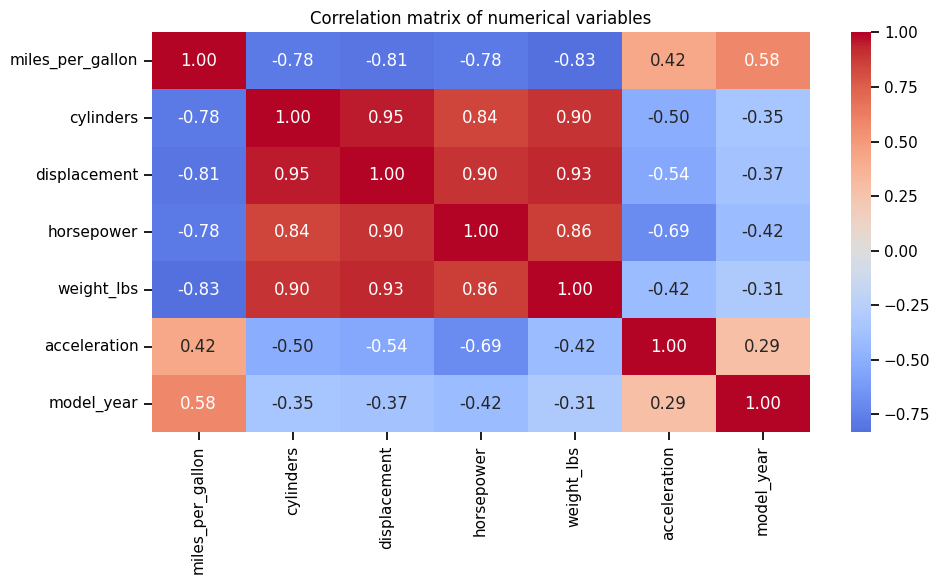

In [7]:
plt.figure(figsize=(10, 6))
corr_global = Automobiledf[num_cols].corr()

sns.heatmap(
    corr_global,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Correlation matrix of numerical variables")
plt.tight_layout()
plt.show()

MPG is strongly negatively correlated with weight, displacement, horsepower and the number of cylinders.  
At the same time, these mechanical variables are strongly correlated with each other, suggesting that they mostly describe a common **vehicle size / power** dimension.

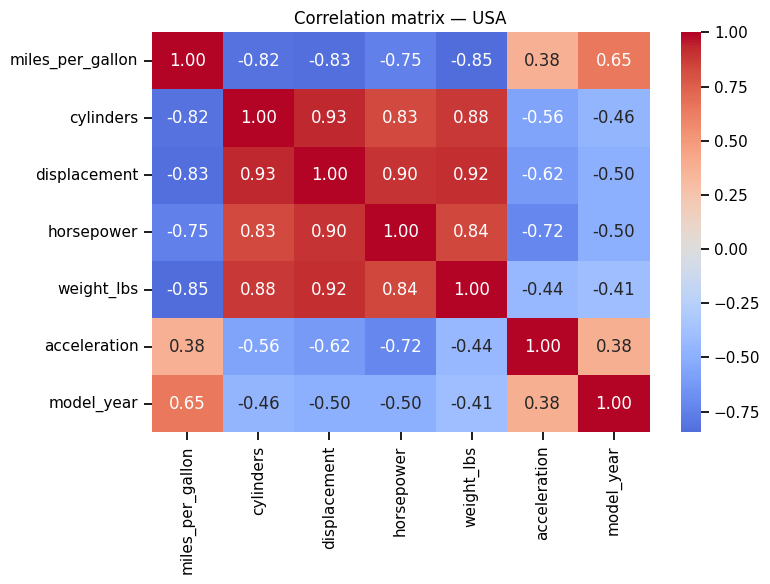

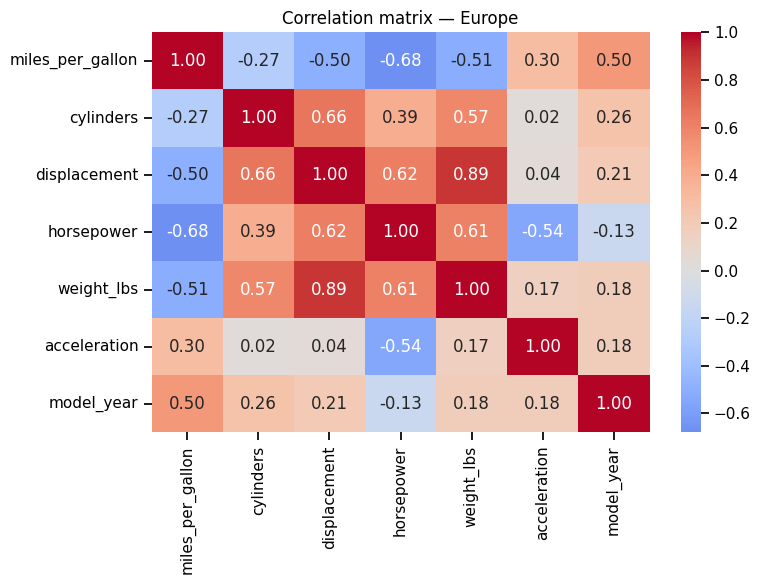

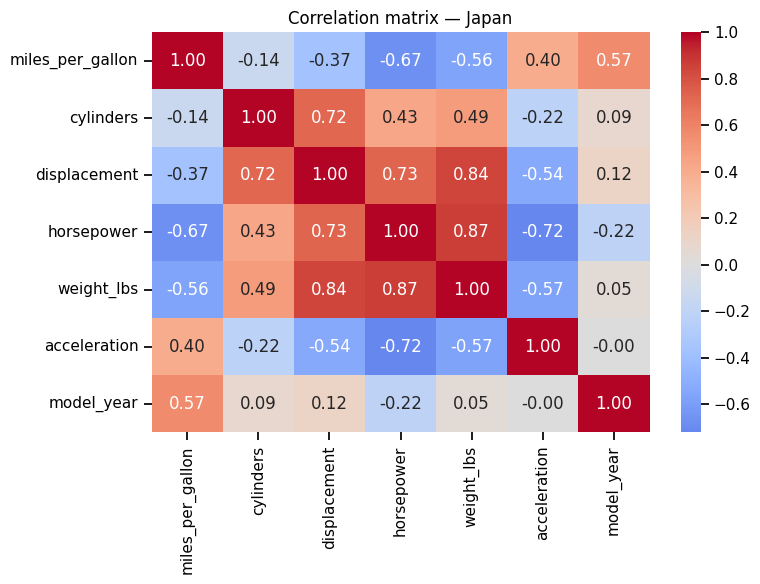

In [8]:
# Correlation structure within each origin
for origin_code, country_name in origin_labels.items():
    subset = Automobiledf.loc[Automobiledf["origin_country"] == origin_code, num_cols]

    plt.figure(figsize=(8, 6))
    sns.heatmap(
        subset.corr(),
        annot=True,
        fmt=".2f",
        cmap="coolwarm",
        center=0
    )
    plt.title(f"Correlation matrix — {country_name}")
    plt.tight_layout()
    plt.show()

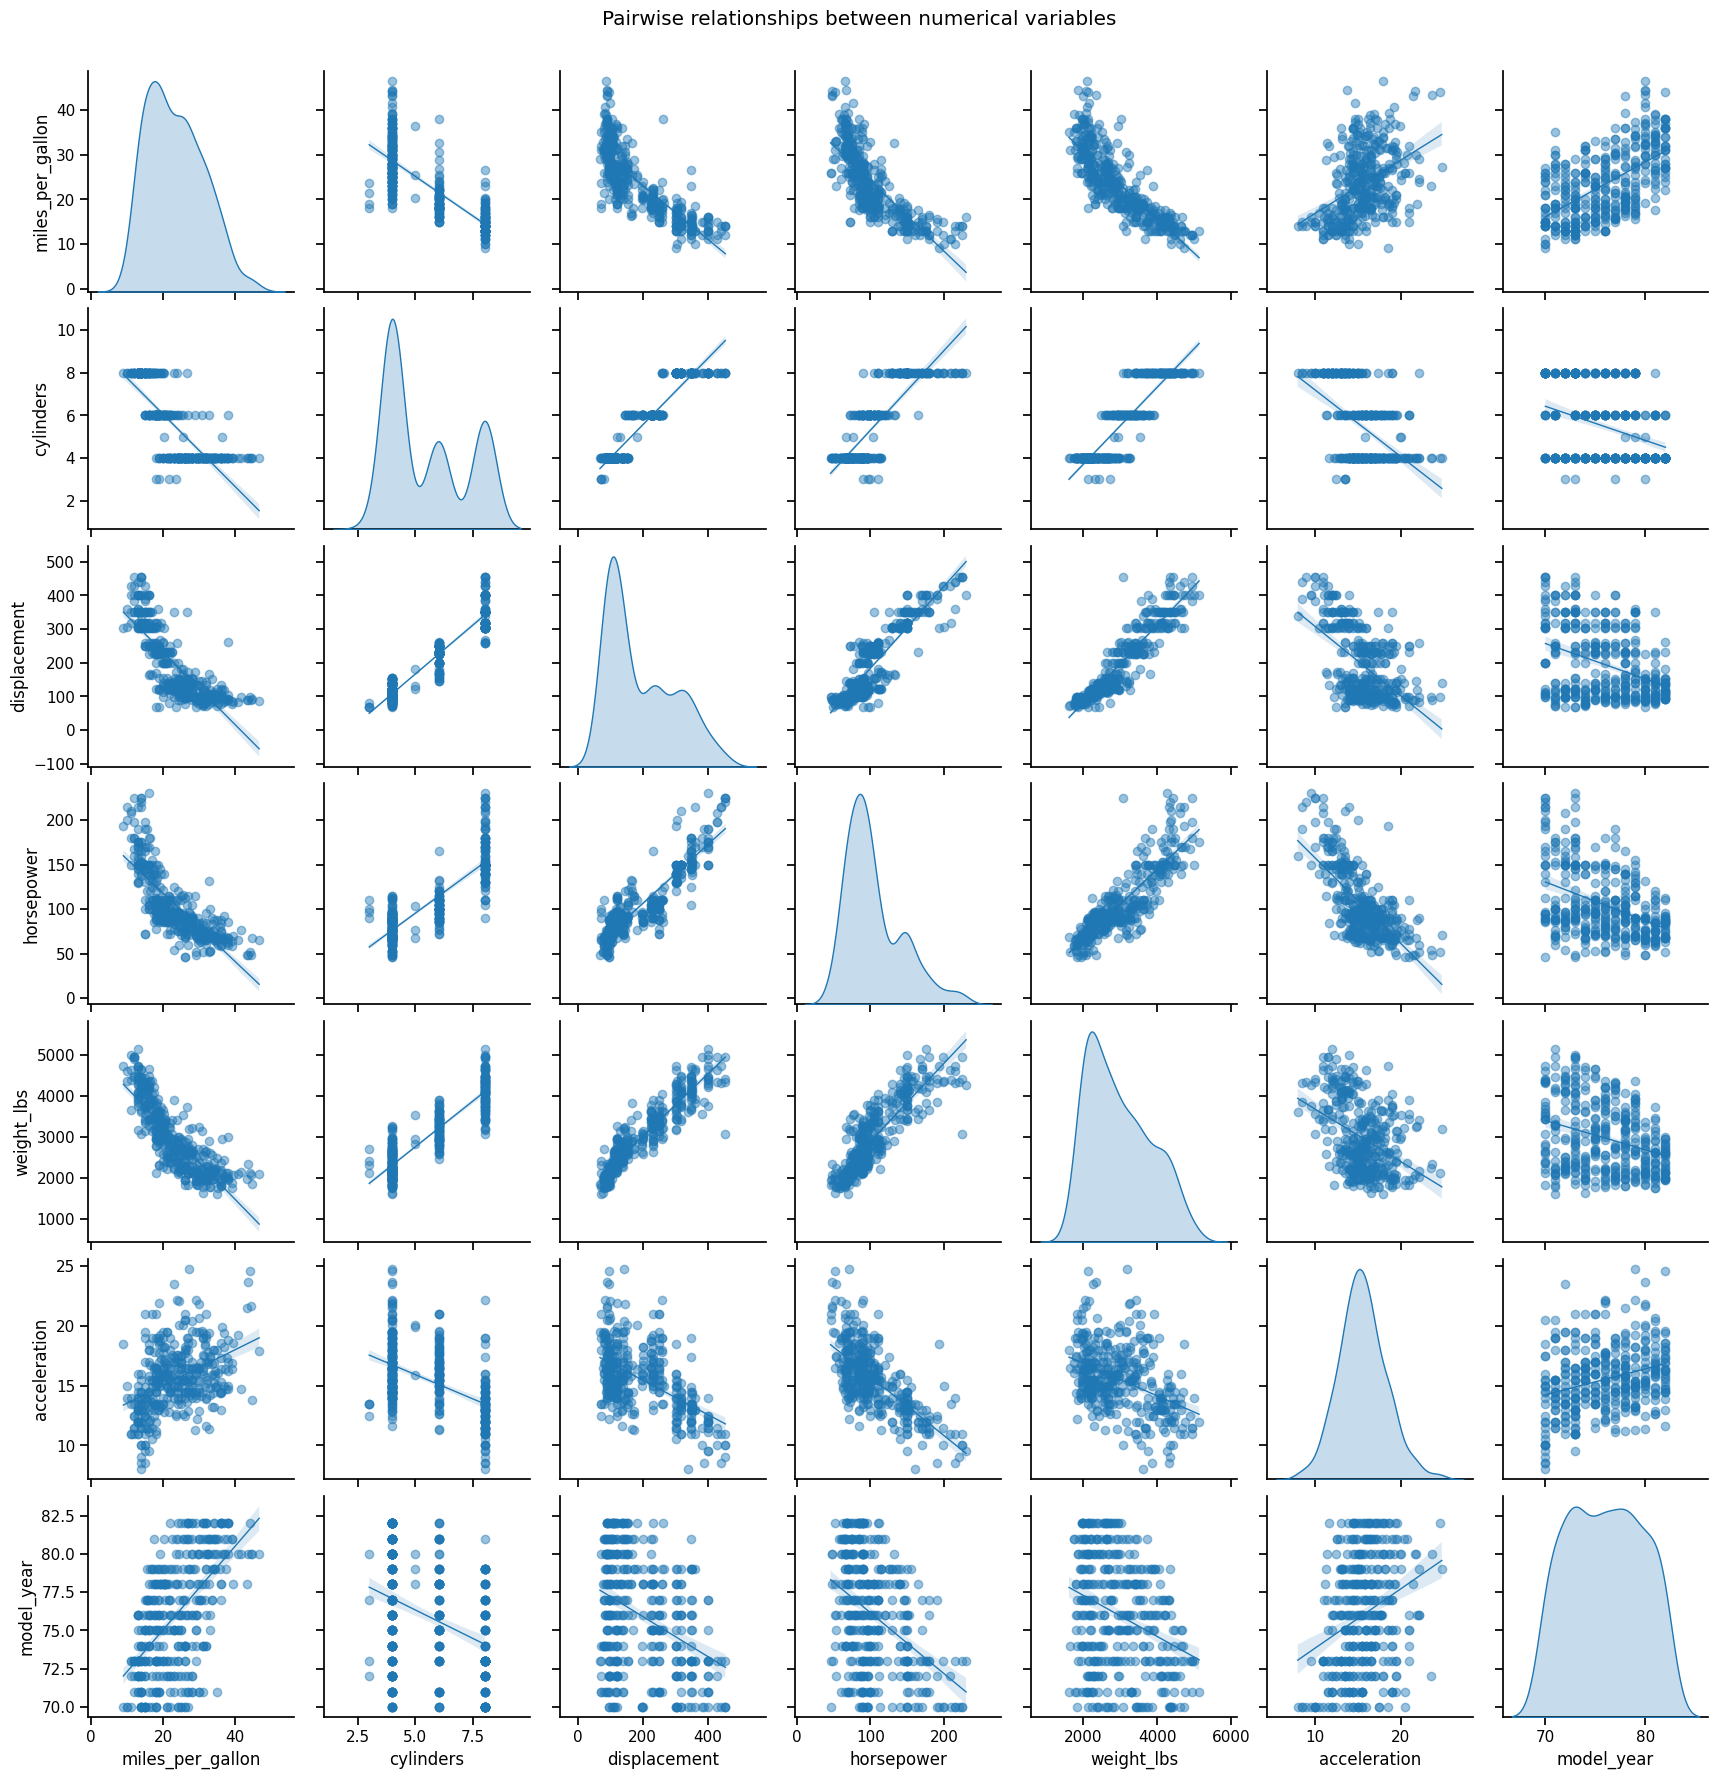

In [9]:
# Pairwise relationships in the full dataset
sns.pairplot(
    Automobiledf[num_cols],
    diag_kind="kde",
    kind="reg",
    plot_kws={"scatter_kws": {"alpha": 0.45}, "line_kws": {"linewidth": 1}}
)
plt.suptitle("Pairwise relationships between numerical variables", y=1.02)
plt.show()

The pairplot makes the same structure easier to see visually. The negative relationship between MPG and weight is especially clear, while acceleration is much more dispersed.

I also check two distributional assumptions that were relevant during the initial exploratory work.

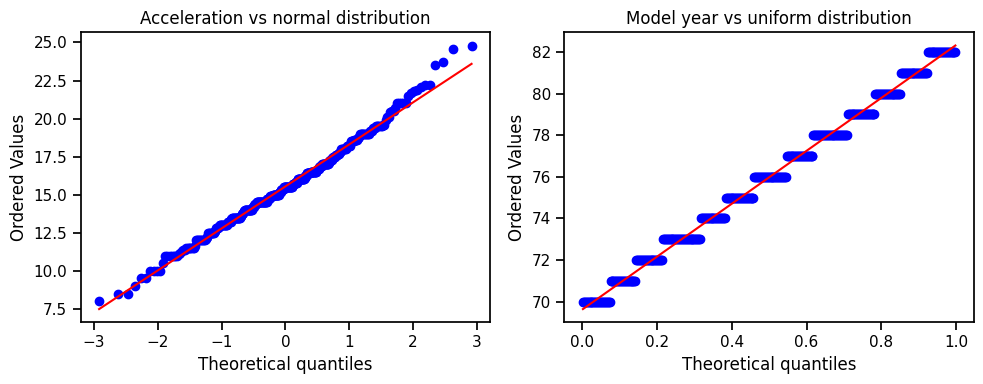

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

stats.probplot(
    Automobiledf["acceleration"],
    dist="norm",
    plot=axes[0]
)
axes[0].set_title("Acceleration vs normal distribution")

stats.probplot(
    Automobiledf["model_year"],
    dist="uniform",
    plot=axes[1]
)
axes[1].set_title("Model year vs uniform distribution")

plt.tight_layout()
plt.show()

Acceleration is reasonably close to a normal distribution over most of its range.  
Model year has the expected step-like QQ pattern because it is discrete, but observations are fairly evenly spread across the considered years.

## 4. Fuel-efficiency standard (24 MPG)

In [11]:
MPG_THRESHOLD = 24

Automobiledf["meets_cafe"] = Automobiledf["miles_per_gallon"] >= MPG_THRESHOLD

cafe_proportion = Automobiledf["meets_cafe"].mean()
print(f"Overall proportion meeting the 24 MPG threshold: {cafe_proportion:.1%}")

Overall proportion meeting the 24 MPG threshold: 46.2%


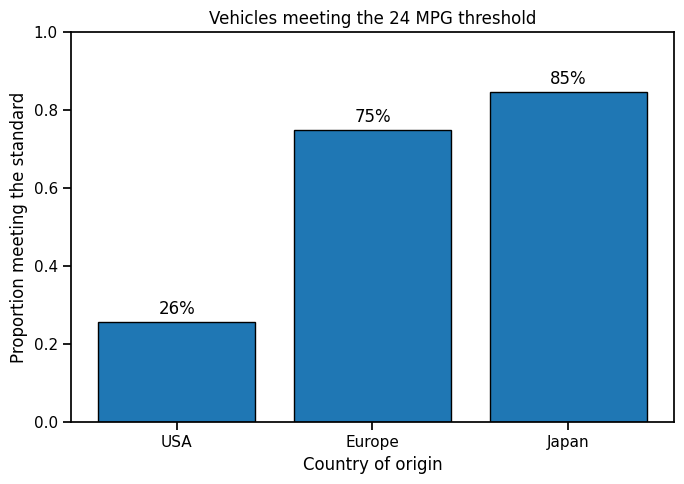

In [12]:
cafe_prop_by_country = (
    Automobiledf
    .groupby("origin_country")["meets_cafe"]
    .mean()
    .rename(index=origin_labels)
)

plt.figure(figsize=(7, 5))
bars = plt.bar(cafe_prop_by_country.index, cafe_prop_by_country.values, edgecolor="black")

plt.ylabel("Proportion meeting the standard")
plt.xlabel("Country of origin")
plt.title("Vehicles meeting the 24 MPG threshold")
plt.ylim(0, 1)

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + 0.02,
        f"{height:.0%}",
        ha="center"
    )

plt.tight_layout()
plt.show()

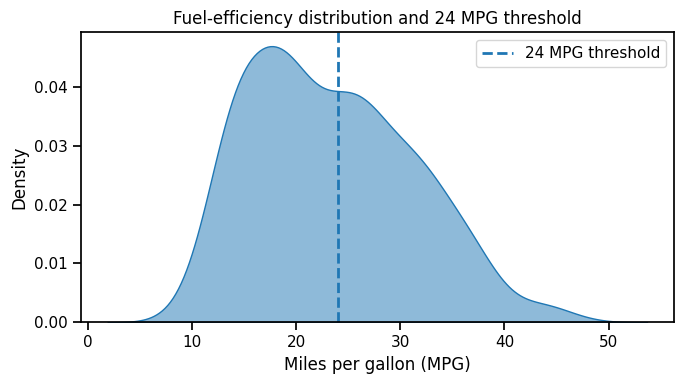

In [13]:
plt.figure(figsize=(7, 4))

sns.kdeplot(
    data=Automobiledf,
    x="miles_per_gallon",
    fill=True,
    alpha=0.5
)

plt.axvline(
    MPG_THRESHOLD,
    linestyle="--",
    linewidth=2,
    label="24 MPG threshold"
)

plt.xlabel("Miles per gallon (MPG)")
plt.ylabel("Density")
plt.title("Fuel-efficiency distribution and 24 MPG threshold")
plt.legend()
plt.tight_layout()
plt.show()

In [14]:
fuel_efficient_df = Automobiledf.loc[Automobiledf["meets_cafe"]].copy()

stats_fuel_efficient = (
    fuel_efficient_df[num_cols]
    .describe()
    .loc[["mean", "std", "min", "max"]]
    .round(2)
)

print(f"Fuel-efficient vehicles: {len(fuel_efficient_df)} / {len(Automobiledf)}")
stats_fuel_efficient

Fuel-efficient vehicles: 181 / 392


,miles_per_gallon,cylinders,displacement,horsepower,weight_lbs,acceleration,model_year
mean,30.53,4.13,112.37,77.69,2300.43,16.49,77.69
std,4.99,0.53,32.80,15.43,374.69,2.45,3.67
min,24.00,4.00,68.00,46.00,1613.00,11.30,70.00
max,46.60,8.00,350.00,132.00,3725.00,24.80,82.00


The threshold does not create two naturally separated groups: MPG remains continuous around 24.  
Still, cars above the threshold are on average lighter, less powerful and more recent, which is consistent with the patterns observed earlier.

## 5. Principal Component Analysis

### 5.1 Global PCA

The numerical variables use very different scales, so they are standardized before PCA.  
This first PCA includes MPG to see how fuel efficiency fits into the overall structure of the dataset.

,Principal component,Explained variance,Cumulative variance
0,PC1,0.716,0.716
1,PC2,0.124,0.839
2,PC3,0.104,0.944
3,PC4,0.026,0.970
4,PC5,0.017,0.987
5,PC6,0.008,0.995
6,PC7,0.005,1.000


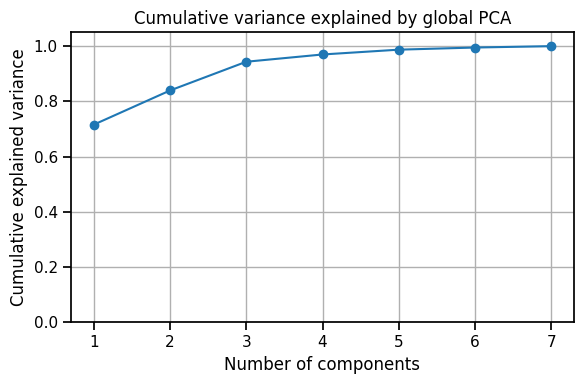

In [15]:
X_global = Automobiledf[num_cols]

scaler_global = StandardScaler()
X_global_scaled = scaler_global.fit_transform(X_global)

pca_global = PCA()
X_global_pca = pca_global.fit_transform(X_global_scaled)

cumulative_variance = np.cumsum(pca_global.explained_variance_ratio_)

variance_table = pd.DataFrame({
    "Principal component": [f"PC{i+1}" for i in range(len(cumulative_variance))],
    "Explained variance": pca_global.explained_variance_ratio_,
    "Cumulative variance": cumulative_variance
})

display(variance_table.round(3))

plt.figure(figsize=(6, 4))
plt.plot(
    range(1, len(cumulative_variance) + 1),
    cumulative_variance,
    marker="o"
)
plt.xlabel("Number of components")
plt.ylabel("Cumulative explained variance")
plt.title("Cumulative variance explained by global PCA")
plt.ylim(0, 1.05)
plt.grid(True)
plt.tight_layout()
plt.show()

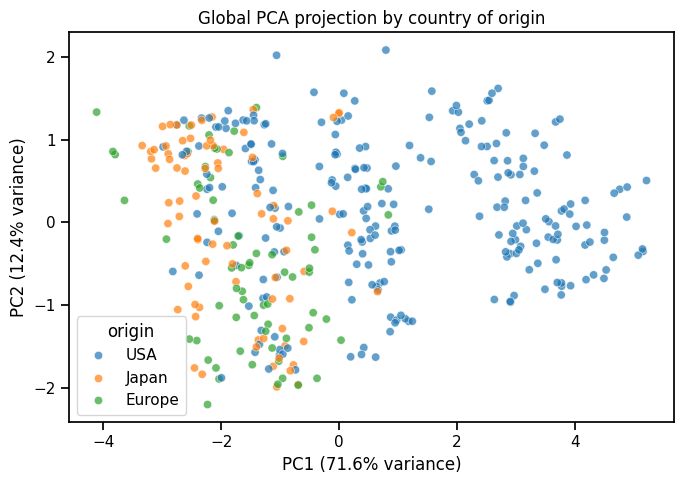

In [16]:
pca_global_2d = pd.DataFrame(
    X_global_pca[:, :2],
    columns=["PC1", "PC2"],
    index=Automobiledf.index
)
pca_global_2d["origin"] = Automobiledf["origin_country"].map(origin_labels)

plt.figure(figsize=(7, 5))
sns.scatterplot(
    data=pca_global_2d,
    x="PC1",
    y="PC2",
    hue="origin",
    alpha=0.7
)

plt.xlabel(f"PC1 ({pca_global.explained_variance_ratio_[0]*100:.1f}% variance)")
plt.ylabel(f"PC2 ({pca_global.explained_variance_ratio_[1]*100:.1f}% variance)")
plt.title("Global PCA projection by country of origin")
plt.tight_layout()
plt.show()

### 5.2 PCA on mechanical variables only

To isolate the mechanical structure, I now keep only cylinders, displacement, horsepower and weight.  
This avoids mixing the mechanical characteristics with MPG, production year and acceleration.

In [17]:
mechanical_cols = ["cylinders", "displacement", "horsepower", "weight_lbs"]

X_mech = Automobiledf[mechanical_cols]

scaler_mech = StandardScaler()
X_mech_scaled = scaler_mech.fit_transform(X_mech)

pca_mech = PCA()
X_mech_pca = pca_mech.fit_transform(X_mech_scaled)

mech_variance = pd.DataFrame({
    "Principal component": [f"PC{i+1}" for i in range(len(mechanical_cols))],
    "Explained variance": pca_mech.explained_variance_ratio_,
    "Cumulative variance": np.cumsum(pca_mech.explained_variance_ratio_)
})

display(mech_variance.round(3))

,Principal component,Explained variance,Cumulative variance
0,PC1,0.924,0.924
1,PC2,0.042,0.965
2,PC3,0.025,0.991
3,PC4,0.009,1.000


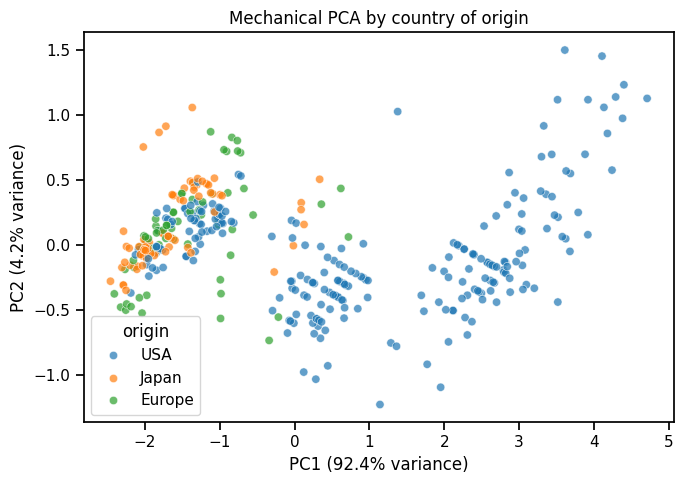

In [18]:
pca_mech_2d = pd.DataFrame(
    X_mech_pca[:, :2],
    columns=["PC1", "PC2"],
    index=Automobiledf.index
)

pca_mech_2d["origin"] = Automobiledf["origin_country"].map(origin_labels)
pca_mech_2d["meets_cafe"] = Automobiledf["meets_cafe"]

plt.figure(figsize=(7, 5))
sns.scatterplot(
    data=pca_mech_2d,
    x="PC1",
    y="PC2",
    hue="origin",
    alpha=0.7
)

plt.xlabel(f"PC1 ({pca_mech.explained_variance_ratio_[0]*100:.1f}% variance)")
plt.ylabel(f"PC2 ({pca_mech.explained_variance_ratio_[1]*100:.1f}% variance)")
plt.title("Mechanical PCA by country of origin")
plt.tight_layout()
plt.show()

In [30]:
mechanical_features = [
    "cylinders",
    "displacement",
    "horsepower",
    "weight_lbs"
]





pc1_loadings = pd.Series(
    pca_mech.components_[0],
    index=mechanical_features
)

pc1_analysis = pd.DataFrame({
    "PC1 loading": pc1_loadings,
    "Contribution to PC1 (%)": (pc1_loadings ** 2) * 100
})

pc1_analysis = pc1_analysis.sort_values(
    "Contribution to PC1 (%)",
    ascending=False
)

pc1_analysis.round(3)





,PC1 loading,Contribution to PC1 (%)
displacement,0.512,26.217
weight_lbs,0.500,25.029
cylinders,0.500,24.990
horsepower,0.487,23.764


In [ ]:
pc2_loadings = pd.Series(
    pca_mech.components_[1],
    index=mechanical_features
)

pc2_analysis = pd.DataFrame({
    "PC2 loading": pc2_loadings,
    "Contribution to PC2 (%)": (pc2_loadings ** 2) * 100
})

pc2_analysis = pc2_analysis.sort_values(
    "Contribution to PC2 (%)",
    ascending=False
)

pc2_analysis.round(3)

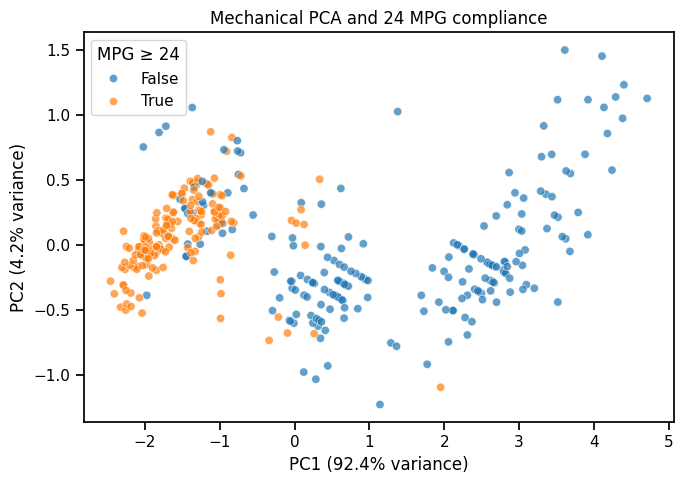

In [19]:
plt.figure(figsize=(7, 5))
sns.scatterplot(
    data=pca_mech_2d,
    x="PC1",
    y="PC2",
    hue="meets_cafe",
    alpha=0.7
)

plt.xlabel(f"PC1 ({pca_mech.explained_variance_ratio_[0]*100:.1f}% variance)")
plt.ylabel(f"PC2 ({pca_mech.explained_variance_ratio_[1]*100:.1f}% variance)")
plt.title("Mechanical PCA and 24 MPG compliance")
plt.legend(title="MPG ≥ 24")
plt.tight_layout()
plt.show()

The first mechanical component explains most of the variance and can be interpreted as a broad size/power axis.  
Fuel-efficient cars are concentrated toward the lighter/smaller-engine side, although the overlap confirms that MPG cannot be reduced to a single mechanical rule.

## 6. Linear regression: predicting MPG

The original analysis used a simple regression between vehicle weight and MPG. I keep that idea because it is easy to interpret, but evaluate it on a held-out test set.

I then compare it with a multivariate linear regression using several vehicle characteristics. This gives a more meaningful view of predictive performance without changing the spirit of the project.

In [20]:
target = "miles_per_gallon"
simple_features = ["weight_lbs"]
multi_features = [
    "cylinders",
    "displacement",
    "horsepower",
    "weight_lbs",
    "acceleration",
    "model_year",
]

X_train_s, X_test_s, y_train, y_test = train_test_split(
    Automobiledf[simple_features],
    Automobiledf[target],
    test_size=0.20,
    random_state=42
)

simple_model = LinearRegression()
simple_model.fit(X_train_s, y_train)

simple_pred = simple_model.predict(X_test_s)

simple_r2 = r2_score(y_test, simple_pred)
simple_rmse = np.sqrt(mean_squared_error(y_test, simple_pred))

print(f"Simple regression — Weight only")
print(f"Test R²   : {simple_r2:.3f}")
print(f"Test RMSE : {simple_rmse:.3f} MPG")
print(f"Equation  : MPG = {simple_model.intercept_:.2f} "
      f"{simple_model.coef_[0]:+.5f} × Weight")

Simple regression — Weight only
Test R²   : 0.653
Test RMSE : 4.206 MPG
Equation  : MPG = 47.20 -0.00790 × Weight


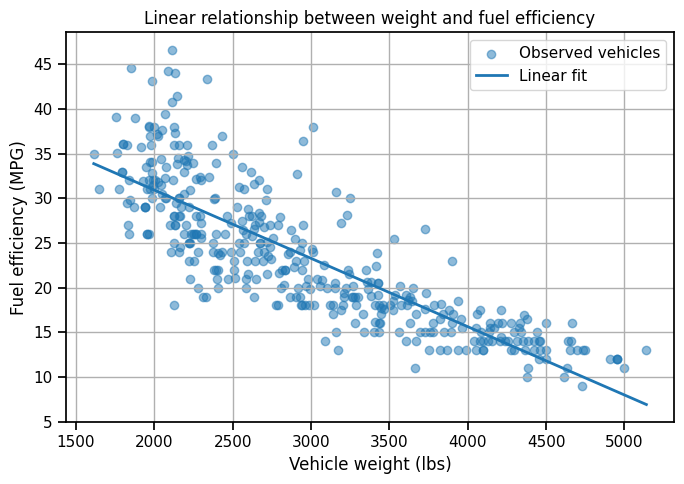

In [21]:
# Visualize the simple relationship using the full dataset
X_weight = Automobiledf[["weight_lbs"]]
y_mpg = Automobiledf["miles_per_gallon"]

display_model = LinearRegression().fit(X_weight, y_mpg)

weight_grid = pd.DataFrame({
    "weight_lbs": np.linspace(
        Automobiledf["weight_lbs"].min(),
        Automobiledf["weight_lbs"].max(),
        200
    )
})

plt.figure(figsize=(7, 5))
plt.scatter(
    Automobiledf["weight_lbs"],
    y_mpg,
    alpha=0.5,
    label="Observed vehicles"
)
plt.plot(
    weight_grid["weight_lbs"],
    display_model.predict(weight_grid),
    linewidth=2,
    label="Linear fit"
)

plt.xlabel("Vehicle weight (lbs)")
plt.ylabel("Fuel efficiency (MPG)")
plt.title("Linear relationship between weight and fuel efficiency")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [22]:
X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(
    Automobiledf[multi_features],
    Automobiledf[target],
    test_size=0.20,
    random_state=42
)

multi_model = LinearRegression()
multi_model.fit(X_train_m, y_train_m)

multi_pred = multi_model.predict(X_test_m)

multi_r2 = r2_score(y_test_m, multi_pred)
multi_rmse = np.sqrt(mean_squared_error(y_test_m, multi_pred))

comparison = pd.DataFrame({
    "Model": ["Weight only", "Multiple vehicle features"],
    "Test R²": [simple_r2, multi_r2],
    "Test RMSE (MPG)": [simple_rmse, multi_rmse],
})

comparison.round(3)

,Model,Test R²,Test RMSE (MPG)
0,Weight only,0.653,4.206
1,Multiple vehicle features,0.794,3.241


In [23]:
coefficients = pd.Series(
    multi_model.coef_,
    index=multi_features,
    name="Coefficient"
).sort_values(key=np.abs, ascending=False)

coefficients.to_frame().round(4)

,Coefficient
model_year,0.7606
cylinders,-0.1162
acceleration,0.0617
weight_lbs,-0.0066
horsepower,-0.0023
displacement,0.0010


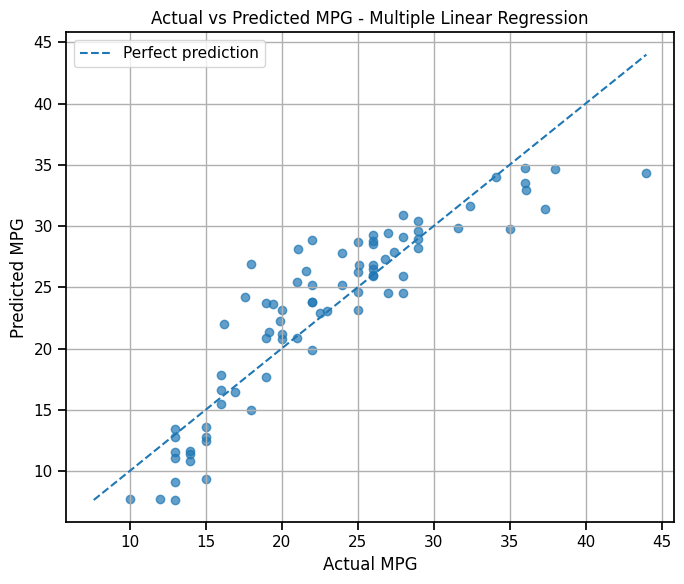

In [24]:
# Compare actual and predicted MPG on the test set

plt.figure(figsize=(7, 6))

plt.scatter(
    y_test_m,
    multi_pred,
    alpha=0.7
)

min_val = min(y_test_m.min(), multi_pred.min())
max_val = max(y_test_m.max(), multi_pred.max())

plt.plot(
    [min_val, max_val],
    [min_val, max_val],
    linestyle="--",
    label="Perfect prediction"
)

plt.xlabel("Actual MPG")
plt.ylabel("Predicted MPG")
plt.title("Actual vs Predicted MPG - Multiple Linear Regression")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

Most predictions are relatively close to the diagonal, indicating that the multiple
linear regression captures a substantial part of the variation in fuel efficiency.

Compared with the weight-only model, the multiple regression achieves a higher R² and
a lower RMSE. This suggests that vehicle weight is an important predictor of fuel
efficiency, but that the other mechanical characteristics and model year provide
additional useful information.

On this fixed train/test split, weight alone already captures a large part of MPG variation, but the multivariate model performs better.  
This supports the exploratory analysis: vehicle weight is a major factor, while production year and the other mechanical variables provide additional information.

The regression remains intentionally simple and interpretable. More complex models could improve prediction, but that is outside the main objective of this analysis.